In [ ]:
# ======================= 📦 1. Imports & Setup =======================
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
import timm
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, auc
import tensorflow as tf
import matplotlib.pyplot as plt
import math
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score, log_loss
)
from sklearn.preprocessing import label_binarize

In [ ]:
# Seeds & Device
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ======================= 📁 2. Dataset Setup =======================
train_data_path = "/kaggle/input/final-alzheimer-dataset/output/Train"
test_data_path = "/kaggle/input/final-alzheimer-dataset/output/Test"

Using device: cuda


In [ ]:
eda_train_dataset = datasets.ImageFolder(train_data_path)
eda_test_dataset = datasets.ImageFolder(test_data_path)
class_names = eda_train_dataset.classes
NUM_CLASSES = len(class_names)
print(eda_train_dataset.classes)
print(eda_train_dataset.classes)

['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'mildDemented']
['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'mildDemented']


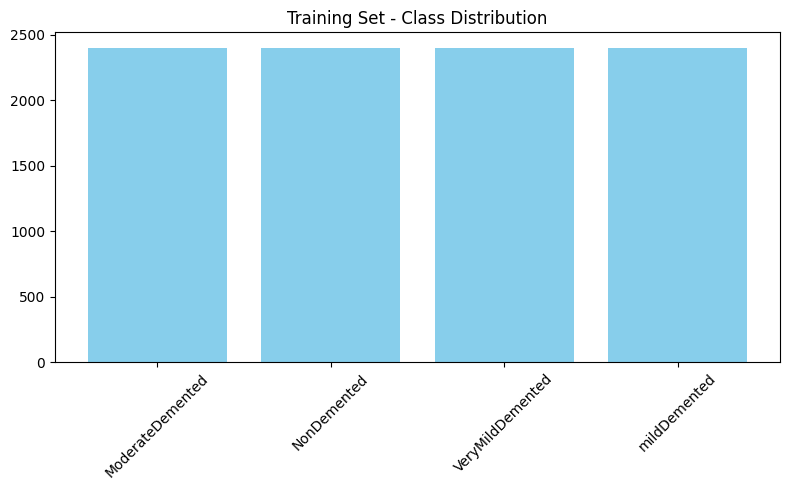

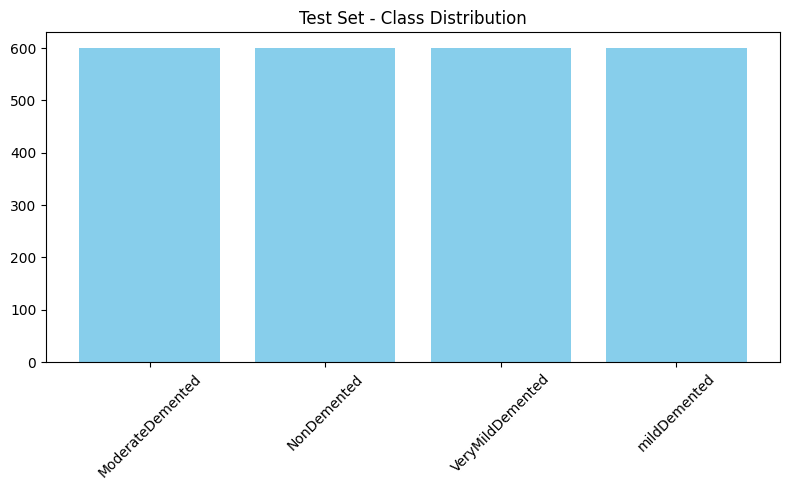

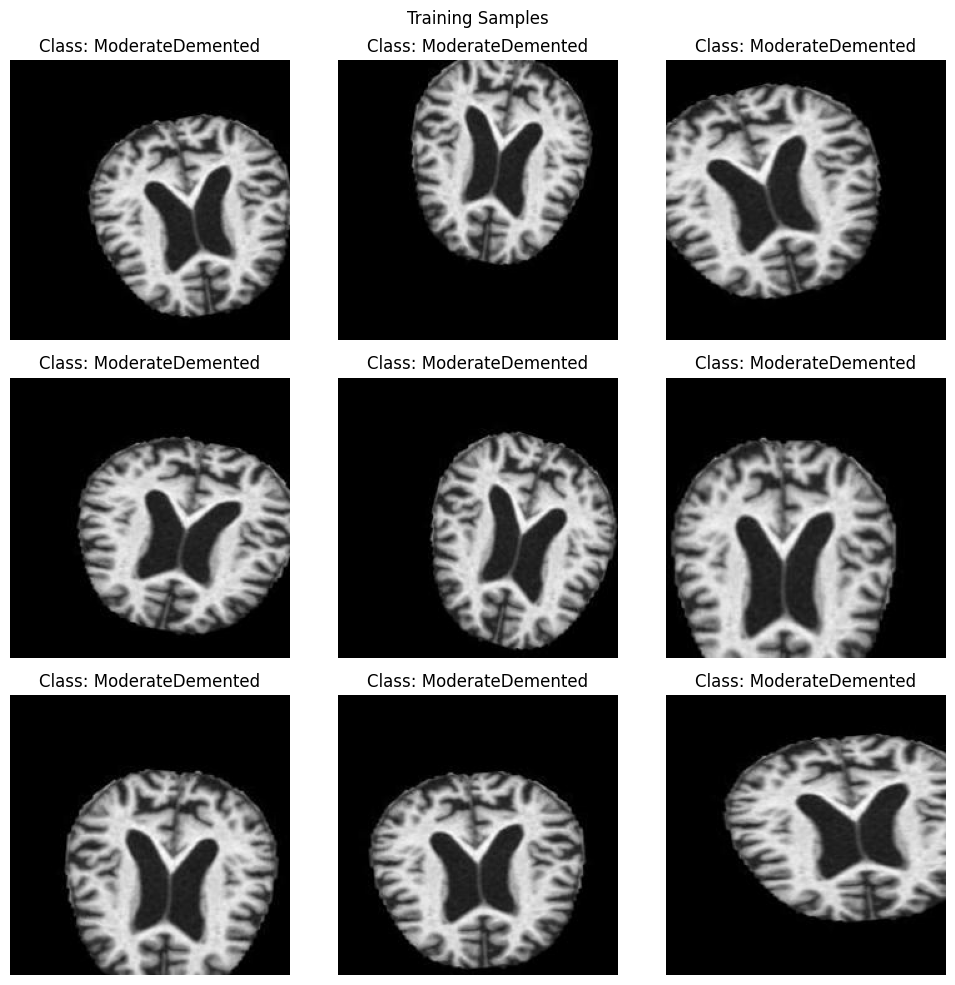

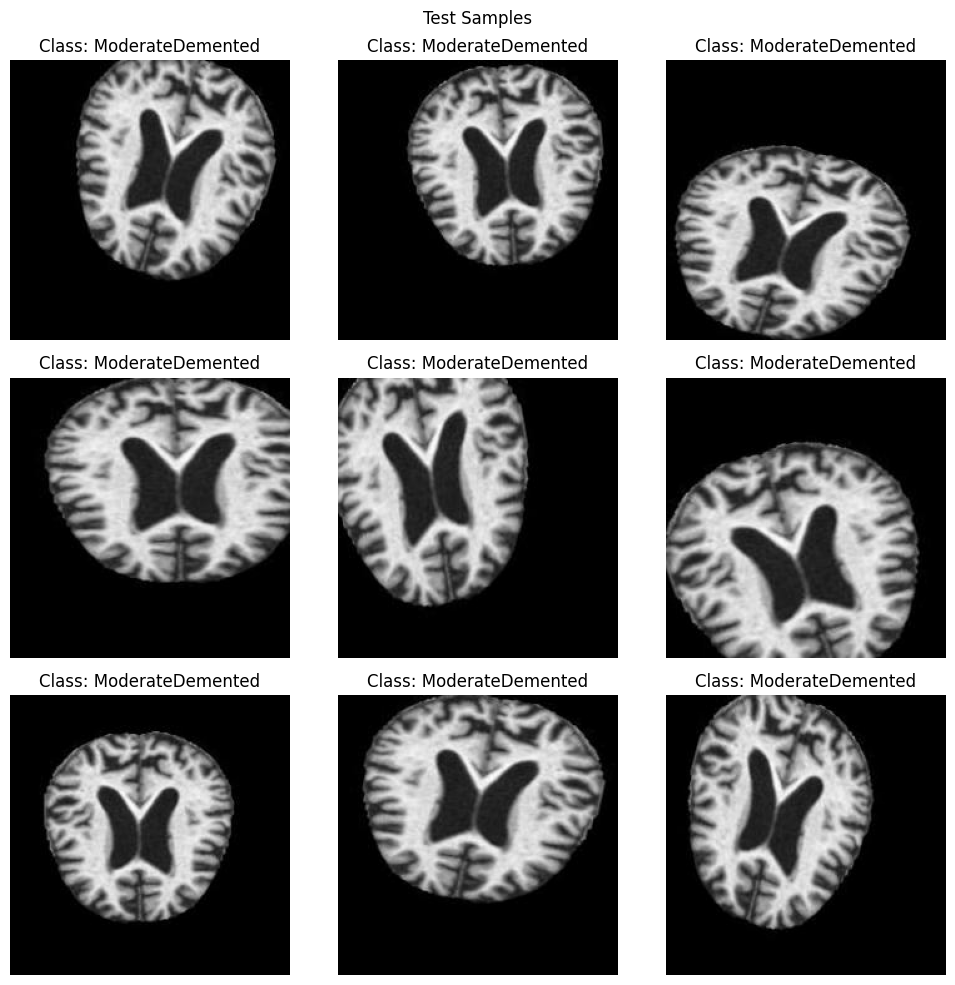

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/50 - Validation: 100%|██████████| 120/120 [00:14<00:00,  8.56it/s]


Epoch 1 — Train Acc: 75.40%, Val Acc: 82.34%


Epoch 2/50 - Validation: 100%|██████████| 120/120 [00:09<00:00, 12.03it/s]


Epoch 2 — Train Acc: 81.24%, Val Acc: 82.34%


...

Epoch 5/50 - Validation: 100%|██████████| 120/120 [00:10<00:00, 11.82it/s]


Epoch 5 — Train Acc: 86.39%, Val Acc: 88.49%


Epoch 6/50 - Validation: 100%|██████████| 120/120 [00:09<00:00, 12.16it/s]


Epoch 6 — Train Acc: 87.76%, Val Acc: 85.78%


Epoch 7/50 - Training:  51%|█████▏    | 247/480 [00:42<00:40,  5.78it/s]

In [ ]:
# ======================= 📊 3. EDA: Class Distribution =======================
def plot_distribution(dataset, title):
    counts = Counter([s[1] for s in dataset.samples])
    named_counts = {class_names[i]: counts[i] for i in counts}
    plt.figure(figsize=(8, 5))
    plt.bar(named_counts.keys(), named_counts.values(), color='skyblue')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_distribution(eda_train_dataset, "Training Set - Class Distribution")
plot_distribution(eda_test_dataset, "Test Set - Class Distribution")

# ======================= 🖼️ 4. Show Sample Images =======================
def show_samples(dataset, title):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for i in range(9):
        img, label = dataset[i]
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {class_names[label]}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(eda_train_dataset, "Training Samples")
show_samples(eda_test_dataset, "Test Samples")

# ======================= 🔄 5. Transforms & Loaders =======================
BATCH_SIZE = 16
IMAGE_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(train_data_path, transform=transform)
test_dataset = datasets.ImageFolder(test_data_path, transform=transform)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ======================= 🧠 6. Model Setup =======================
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=NUM_CLASSES,
    features_only=False
)
for param in model.parameters():
    param.requires_grad = True
model.to(device)

# ======================= 💾 7. Save Directories & Init Checkpoint =======================
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("logs", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/initial_model.pth")

# ======================= 🎯 8. Optimizer, Scheduler =======================
LEARNING_RATE = 0.00001
NUM_EPOCHS = 50

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=2)

# ======================= 🏋️ 9. Training Loop =======================
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_acc = 100 * correct / total
    train_loss = total_loss / len(train_loader)
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    total_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
    val_acc = 100 * correct_val / total_val
    val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1} — Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, f"checkpoints/best_model_epoch_{epoch+1}_acc_{val_acc:.2f}.pth")

In [ ]:
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score,
    accuracy_score, log_loss, balanced_accuracy_score, matthews_corrcoef
)
import pandas as pd

# Function to compute evaluation metrics for a given data loader
def compute_metrics(model, data_loader, class_names, set_name, save_path):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Compute metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    accuracy = accuracy_score(all_labels, all_preds)
    logloss = log_loss(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)

    # Save classification report to CSV
    pd.DataFrame(report).transpose().to_csv(save_path)

    # Print metrics
    print(f"\n{set_name} Evaluation Metrics:")
    print(f"Classification Report:\n{classification_report(all_labels, all_preds, target_names=class_names)}")
    print(f"F1 Score (Weighted): {f1:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted): {recall:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Log Loss: {logloss:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# Ensure model is loaded with best weights
model.load_state_dict(best_model_wts)

# Compute metrics for training set
compute_metrics(
    model,
    train_loader,
    class_names,
    set_name="Training Set",
    save_path="logs/classification_report_train.csv"
)

# Compute metrics for validation set
compute_metrics(
    model,
    val_loader,
    class_names,
    set_name="Validation Set",
    save_path="logs/classification_report_val.csv"
)


Training Set Evaluation Metrics:
Classification Report:
                  precision    recall  f1-score   support

ModerateDemented       1.00      1.00      1.00      1922
     NonDemented       1.00      1.00      1.00      1941
VeryMildDemented       1.00      1.00      1.00      1927
    mildDemented       1.00      1.00      1.00      1890

        accuracy                           1.00      7680
       macro avg       1.00      1.00      1.00      7680
    weighted avg       1.00      1.00      1.00      7680

F1 Score (Weighted): 0.9999
Precision (Weighted): 0.9999
Recall (Weighted): 0.9999
Accuracy: 0.9999
Log Loss: 0.0014
Balanced Accuracy: 0.9999
Matthews Correlation Coefficient: 0.9998

Validation Set Evaluation Metrics:
Classification Report:
                  precision    recall  f1-score   support

ModerateDemented       1.00      1.00      1.00       478
     NonDemented       0.99      0.99      0.99       459
VeryMildDemented       0.98      0.99      0.99       473


✅ All training states saved.


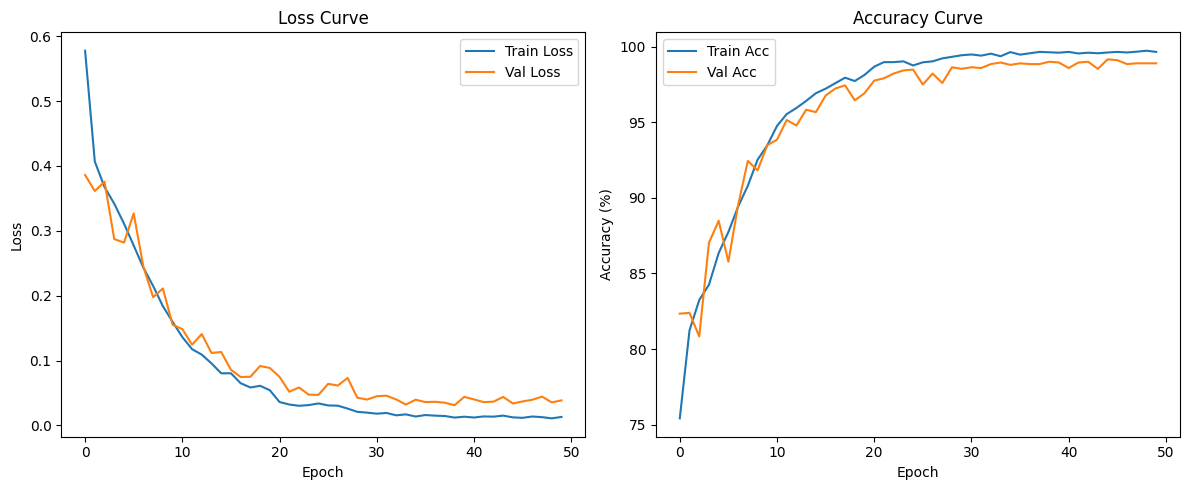

Classification Report:
                  precision    recall  f1-score   support

ModerateDemented       1.00      1.00      1.00       600
     NonDemented       0.98      0.90      0.94       600
VeryMildDemented       0.91      0.98      0.94       600
    mildDemented       0.99      0.99      0.99       600

        accuracy                           0.97      2400
       macro avg       0.97      0.97      0.97      2400
    weighted avg       0.97      0.97      0.97      2400

F1 Score: 0.9687502802615775
Precision: 0.9703026979206942
Recall: 0.96875
Accuracy: 0.96875
Log Loss: 0.09996200993538763


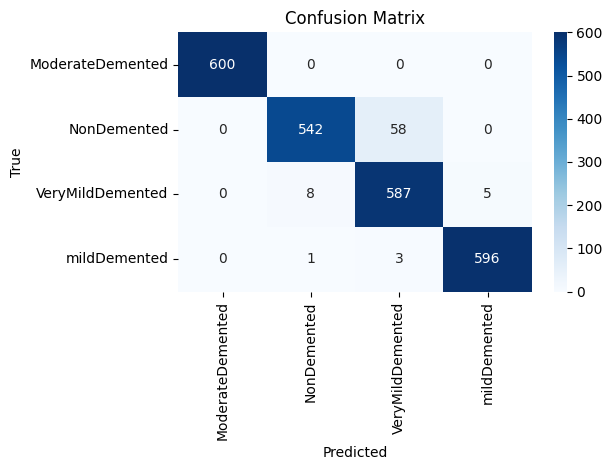

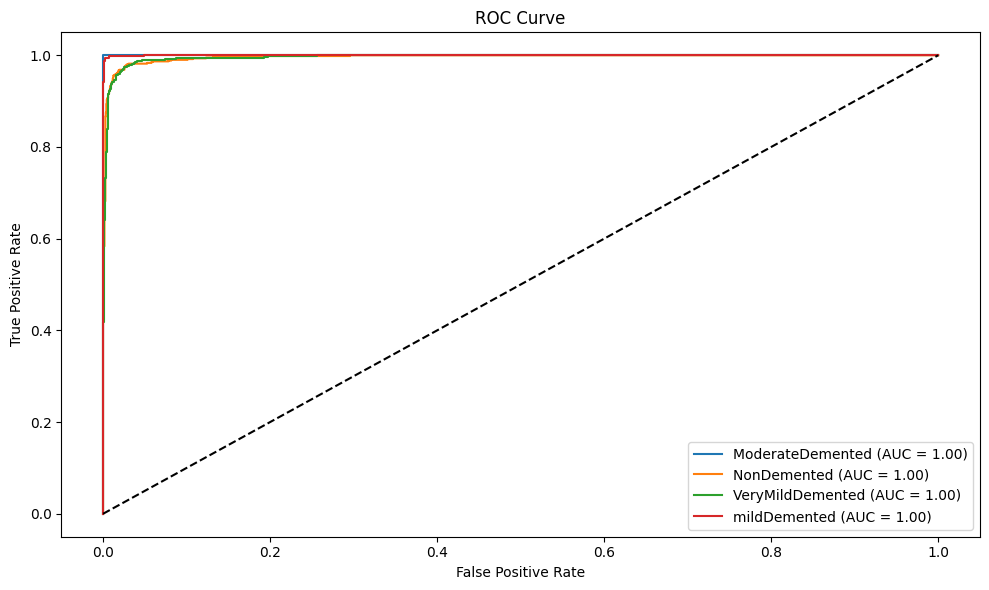

✅ All training states saved.


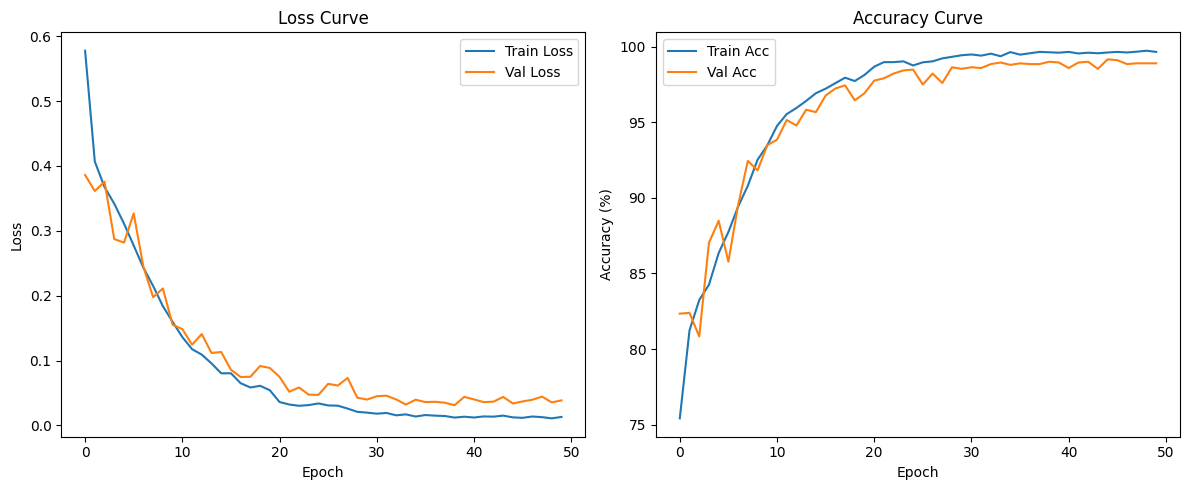

Classification Report:
                  precision    recall  f1-score   support

ModerateDemented       1.00      1.00      1.00       600
     NonDemented       0.98      0.92      0.95       600
VeryMildDemented       0.92      0.98      0.95       600
    mildDemented       0.99      0.99      0.99       600

        accuracy                           0.97      2400
       macro avg       0.97      0.97      0.97      2400
    weighted avg       0.97      0.97      0.97      2400

F1 Score: 0.9721160562932561
Precision: 0.9732840985085391
Recall: 0.9720833333333333
Accuracy: 0.9720833333333333
Log Loss: 0.10052550649028952


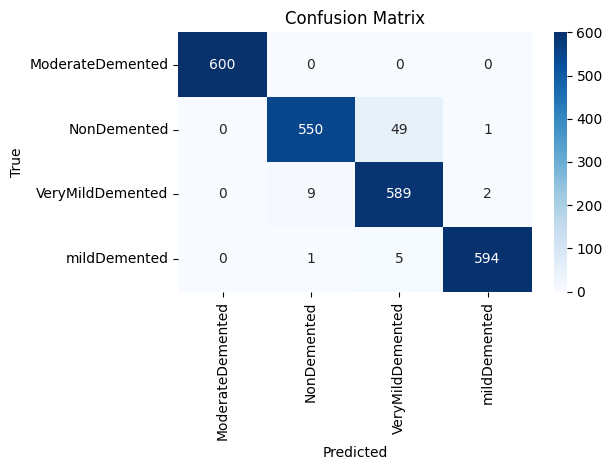

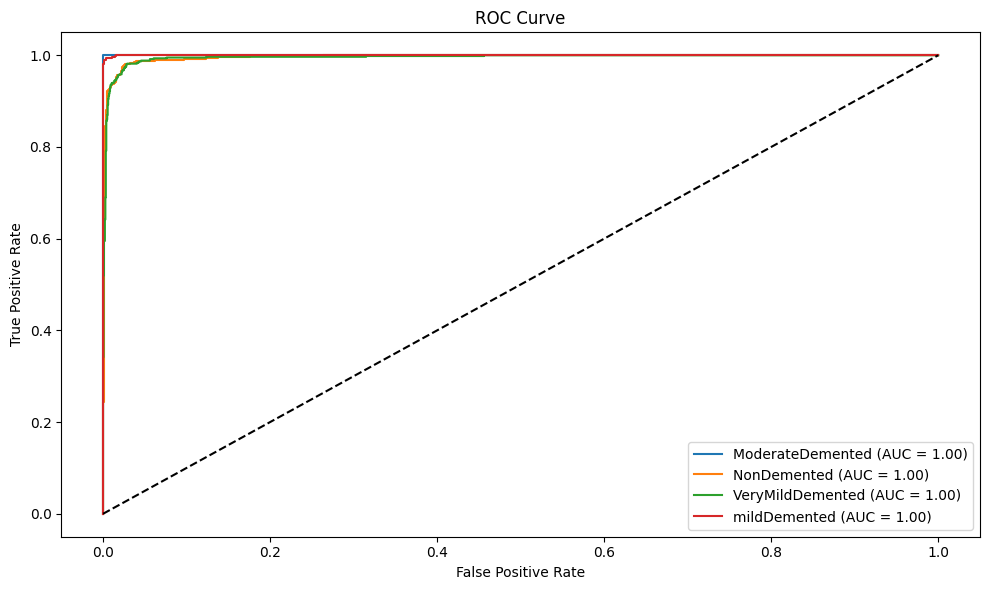

Number of replicas: 1
2.15.0


In [ ]:
# ======================= 💾 10. Save Final State =======================
# 1️⃣ Save final model weights and best weights
final_path = "/kaggle/working/vit.pth"
torch.save(model.state_dict(), final_path)
torch.save(best_model_wts, "checkpoints/best_model.pth")

# 2️⃣ Save full training state for reproducibility
torch.save({
    'model_state_dict': model.state_dict(),
    'best_model_state_dict': best_model_wts,
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_loss_history': train_loss_history,
    'val_loss_history': val_loss_history,
    'train_acc_history': train_acc_history,
    'val_acc_history': val_acc_history,
    'class_names': class_names,
    'epochs_trained': NUM_EPOCHS
}, "checkpoints/full_training_state.pth")
print("✅ All training states saved.")

# ======================= 📈 11. Loss & Accuracy Curves =======================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.savefig("logs/loss_accuracy_curves.png")
plt.show()

# ======================= 📊 12. Evaluation: Classification Report & Metrics =======================
model.load_state_dict(best_model_wts)
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
pd.DataFrame(report).transpose().to_csv("logs/classification_report.csv")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))
print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall:", recall_score(all_labels, all_preds, average='weighted'))
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Log Loss:", log_loss(all_labels, all_probs))

# ======================= 🔀 13. Confusion Matrix =======================
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("logs/confusion_matrix.png")
plt.show()

# ======================= 📉 14. ROC Curve =======================
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
all_probs = np.array(all_probs)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = roc_auc_score(y_true_bin[:, i], all_probs[:, i])

plt.figure(figsize=(10, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("logs/roc_curve.png")
plt.show()

# ======================= ✅ DONE =======================import os
# ======================= 💾 10. Save Final State =======================
# 1️⃣ Save final model weights and best weights
final_path = "/kaggle/working/vit.pth"
torch.save(model.state_dict(), final_path)
torch.save(best_model_wts, "checkpoints/best_model.pth")

# 2️⃣ Save full training state for reproducibility
torch.save({
    'model_state_dict': model.state_dict(),
    'best_model_state_dict': best_model_wts,
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_loss_history': train_loss_history,
    'val_loss_history': val_loss_history,
    'train_acc_history': train_acc_history,
    'val_acc_history': val_acc_history,
    'class_names': class_names,
    'epochs_trained': NUM_EPOCHS
}, "checkpoints/full_training_state.pth")
print("✅ All training states saved.")

# ======================= 📈 11. Loss & Accuracy Curves =======================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.savefig("logs/loss_accuracy_curves.png")
plt.show()

# ======================= 📊 12. Evaluation: Classification Report & Metrics =======================
model.load_state_dict(best_model_wts)
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
pd.DataFrame(report).transpose().to_csv("logs/classification_report.csv")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("F1 Score:", f1_score(all_labels, all_preds, average='weighted'))
print("Precision:", precision_score(all_labels, all_preds, average='weighted'))
print("Recall:", recall_score(all_labels, all_preds, average='weighted'))
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Log Loss:", log_loss(all_labels, all_probs))

# ======================= 🔀 13. Confusion Matrix =======================
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("logs/confusion_matrix.png")
plt.show()

# ======================= 📉 14. ROC Curve =======================
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
all_probs = np.array(all_probs)
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = roc_auc_score(y_true_bin[:, i], all_probs[:, i])

plt.figure(figsize=(10, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("logs/roc_curve.png")
plt.show()

# ======================= ✅ DONE =======================
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Device:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()
print('Number of replicas:', strategy.num_replicas_in_sync)

print(tf.__version__)

Generating Styled Precision-Recall Curve...


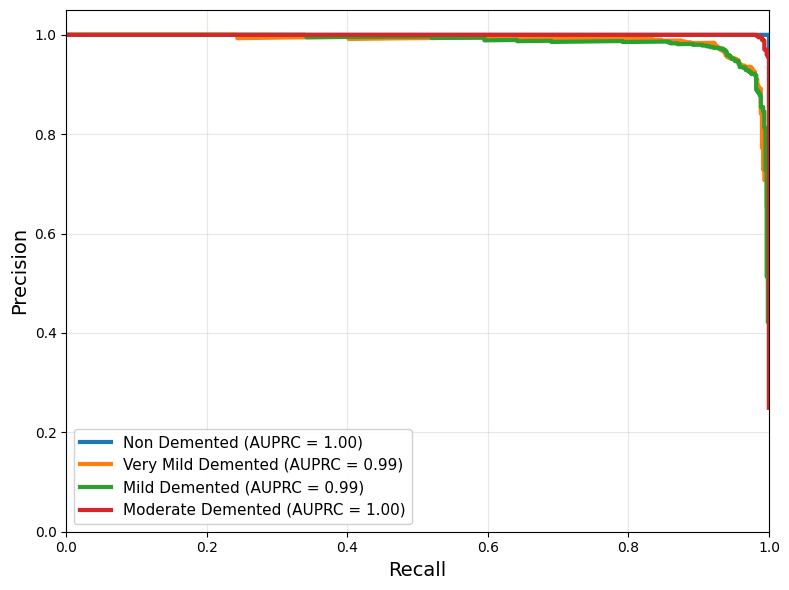

Generating Styled ROC Curve...


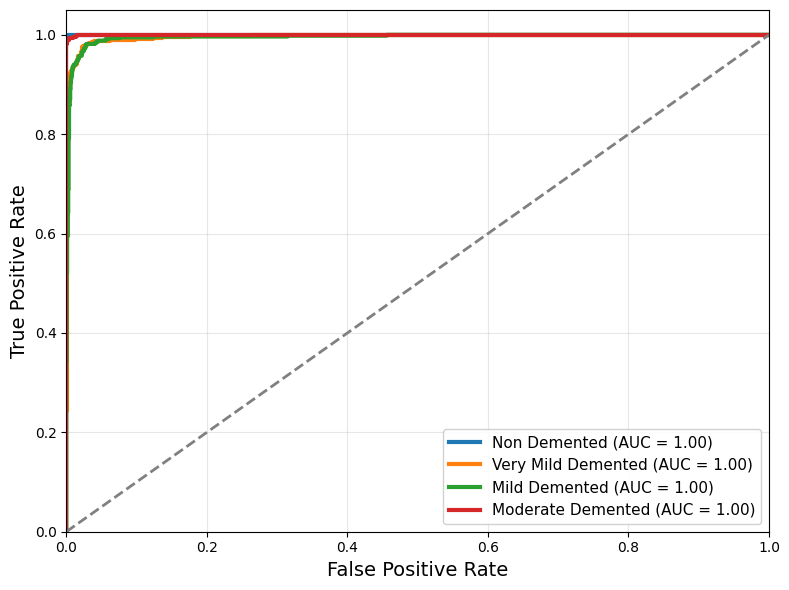

In [ ]:
# Define the save directory path and ensure it exists
save_dir = "logs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. Define the specific class names and colors
CLASS_NAMES = ['Non Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']
NUM_CLASSES = len(CLASS_NAMES)
# Use a color palette suitable for a small number of classes
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red
MODEL_NAME = "Multi-Class Model" # Placeholder for your model name

# --- Data Preparation (using your original logic) ---
# NOTE: Replace the following placeholder data with your actual model evaluation results
# for 'all_labels' and 'all_probs'.

# Placeholder values for all_labels and all_probs for testing/structural purposes:
# If you run this code, replace the following with your actual data:
# For execution without real data, this block generates dummy data:
if 'all_labels' not in locals() or 'all_probs' not in locals():
    np.random.seed(42)
    N_SAMPLES = 100
    all_labels = np.random.randint(0, NUM_CLASSES, N_SAMPLES)
    # Generate random probabilities that sum to 1
    all_probs = np.random.rand(N_SAMPLES, NUM_CLASSES)
    all_probs = all_probs / all_probs.sum(axis=1)[:, np.newaxis]


# Binarize the true labels for multi-class metrics
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
all_probs = np.array(all_probs)


# ##################################################################
# 1. Styled Precision-Recall Curve Plot
# ##################################################################
print("Generating Styled Precision-Recall Curve...")
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    # Use auc(recall, precision) for AUPRC calculation
    auprc = auc(recall, precision)
    plt.plot(
        recall, precision,
        color=COLORS[i],
        lw=3,
        label=f'{CLASS_NAMES[i]} (AUPRC = {auprc:.2f})'
    )

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
#plt.title(f'{MODEL_NAME} - Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
pr_save_path = os.path.join(save_dir, f"{MODEL_NAME.lower().replace(' ', '_')}_pr_curve.png")
plt.savefig(pr_save_path, dpi=300, bbox_inches='tight')
plt.show()

# ##################################################################
# 2. Styled ROC Curve Plot
# ##################################################################
print("Generating Styled ROC Curve...")
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    # Use auc(fpr, tpr) for ROC AUC calculation
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=COLORS[i],
        lw=3,
        label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})'
    )

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title(f'{MODEL_NAME} - ROC Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
roc_save_path = os.path.join(save_dir, f"{MODEL_NAME.lower().replace(' ', '_')}_roc_curve.png")
plt.savefig(roc_save_path, dpi=300, bbox_inches='tight')
plt.show()

# Clean up placeholder definitions if necessary
if 'N_SAMPLES' in locals():
    del all_labels, all_probs, N_SAMPLES

Searching test set for correctly predicted images...
Images found! Generating precise LayerCAMs...


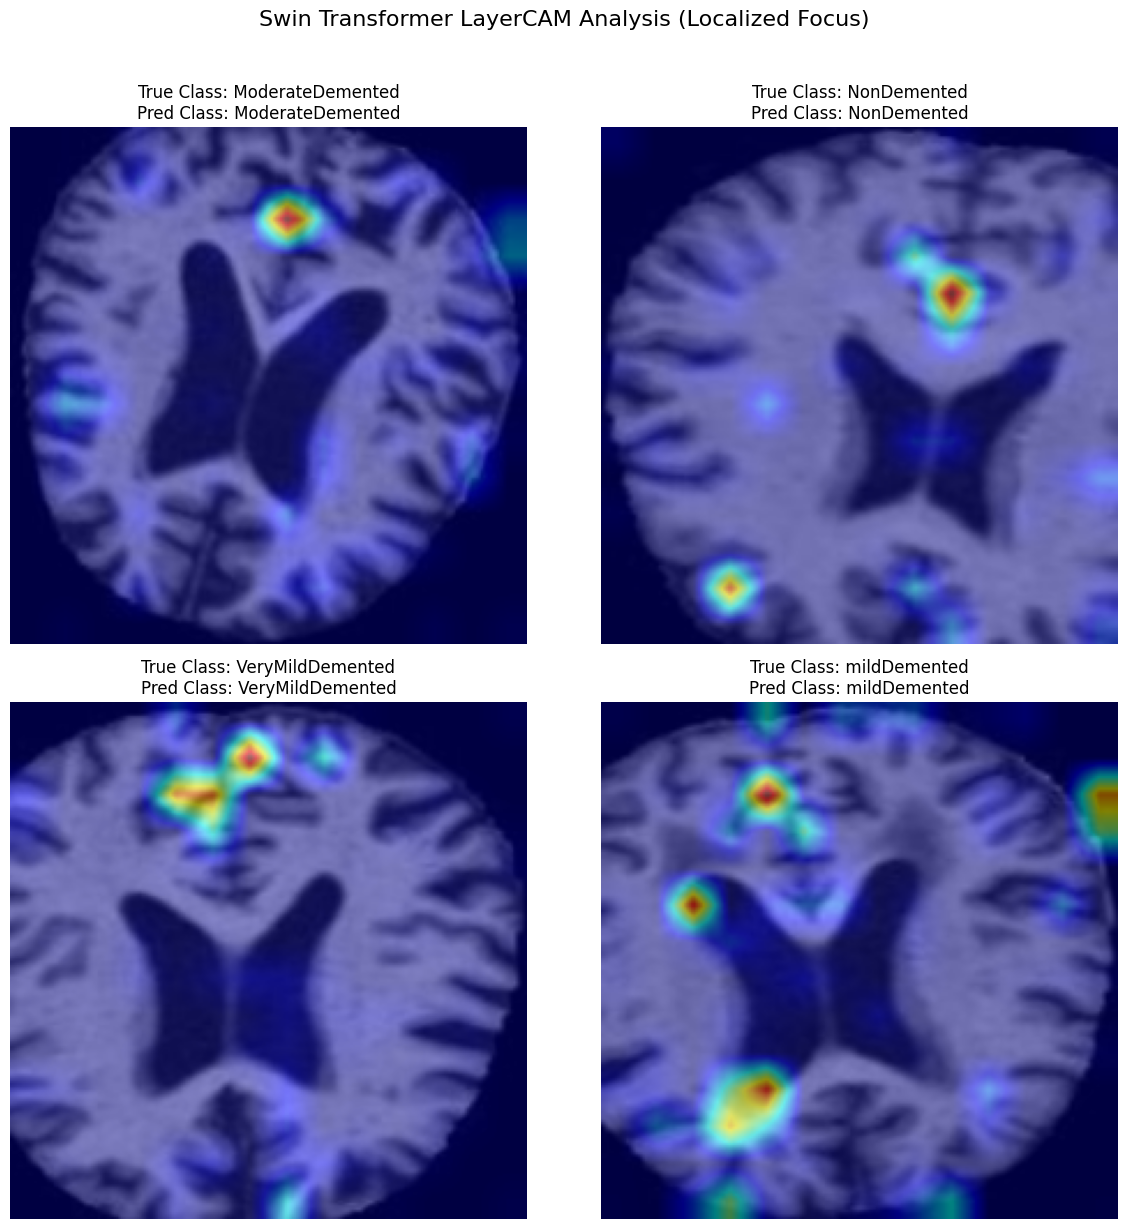

Saved high-resolution image to Swin_LayerCAM_Localized.png


In [ ]:
# 1. Import LayerCAM
from pytorch_grad_cam import LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. Swin Reshape Function (Same as before)
def swin_reshape_transform(tensor):
    if len(tensor.shape) == 4:
        result = tensor.permute(0, 3, 1, 2)
    elif len(tensor.shape) == 3:
        batch_size, length, channels = tensor.shape
        height = int(math.sqrt(length))
        result = tensor.reshape(batch_size, height, height, channels)
        result = result.permute(0, 3, 1, 2)
    return result

# 3. CLINICAL FIX: Target an earlier, more localized layer
# Instead of layers[-1], we target layers[-2] for finer anatomical detail
target_layers = [model.layers[-2].blocks[-1].norm2]

class_names = val_dataset.classes
found_classes = {}

print("Searching test set for correctly predicted images...")
model.eval()

# 4. Find one correct image per class
for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(labels)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        if true_label == pred_label and true_label not in found_classes:
            img_tensor = images[i].unsqueeze(0)

            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
            rgb_img = images[i] * std + mean
            rgb_img = rgb_img.permute(1, 2, 0).cpu().numpy()
            rgb_img = np.clip(rgb_img, 0, 1)

            found_classes[true_label] = (img_tensor, rgb_img, class_names[true_label])

    if len(found_classes) == 4:
        break

print("Images found! Generating precise LayerCAMs...")

# 5. Initialize LayerCAM (The tool for sharp medical localization)
cam = LayerCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=swin_reshape_transform
)

# 6. Plot the 2x2 Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Swin Transformer LayerCAM Analysis (Localized Focus)", fontsize=16, y=1.02)
axes = axes.flatten()

for idx, class_idx in enumerate(sorted(found_classes.keys())):
    img_tensor, rgb_img, class_name = found_classes[class_idx]

    targets = [ClassifierOutputTarget(class_idx)]

    # Generate Heatmap
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[idx].imshow(visualization)
    axes[idx].set_title(f"True Class: {class_name}\nPred Class: {class_name}", fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

fig.savefig('Swin_LayerCAM_Localized.png', dpi=300, bbox_inches='tight')
print("Saved high-resolution image to Swin_LayerCAM_Localized.png")